In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from PIL import Image
from IPython.display import display
import sys

In [19]:
all_tracts = pd.read_csv("NRI_Table_CensusTracts.csv")
state_tracts_maine = all_tracts[all_tracts["STATE"] == "Maine"]
state_tracts_maine

,OID_,NRI_ID,STATE,STATEABBRV,STATEFIPS,COUNTY,COUNTYTYPE,COUNTYFIPS,STCOFIPS,TRACT,...,WNTW_EALS,WNTW_EALR,WNTW_ALRB,WNTW_ALRP,WNTW_ALRA,WNTW_ALR_NPCTL,WNTW_RISKV,WNTW_RISKS,WNTW_RISKR,NRI_VER
33377,34257,T23001010100,Maine,ME,23,Androscoggin,County,1,23001,10100,...,90.470475,Relatively High,5.866778e-06,5.562923e-07,9.097421e-07,62.748005,25222.758593,93.947591,Relatively High,December 2025
33378,34258,T23001010200,Maine,ME,23,Androscoggin,County,1,23001,10200,...,98.152463,Very High,5.866778e-06,5.562923e-07,9.097523e-07,67.752830,51252.957713,98.058796,Very High,December 2025
33379,34259,T23001010300,Maine,ME,23,Androscoggin,County,1,23001,10300,...,94.520935,Relatively High,5.866778e-06,5.562923e-07,9.097421e-07,52.645391,27190.496925,94.583934,Relatively High,December 2025
33380,34260,T23001010400,Maine,ME,23,Androscoggin,County,1,23001,10400,...,92.242698,Relatively High,5.866778e-06,5.562923e-07,9.117155e-07,56.331050,25826.525978,94.139447,Relatively High,December 2025
33381,34261,T23001010500,Maine,ME,23,Androscoggin,County,1,23001,10500,...,91.353056,Relatively High,5.866778e-06,5.562923e-07,9.097421e-07,48.817341,18166.421648,90.191499,Relatively High,December 2025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33772,34652,T23031036003,Maine,ME,23,York,County,31,23031,36003,...,47.342842,Relatively Low,1.308731e-07,4.372038e-08,6.656090e-07,23.467250,2515.005359,47.253834,Relatively Low,December 2025
33773,34653,T23031036004,Maine,ME,23,York,County,31,23031,36004,...,51.633364,Relatively Moderate,1.314387e-07,4.382904e-08,6.739752e-07,23.769682,2809.955861,49.695532,Relatively Moderate,December 2025
33774,34654,T23031037000,Maine,ME,23,York,County,31,23031,37000,...,62.883335,Relatively Moderate,1.323815e-07,4.407961e-08,6.737394e-07,21.509096,3035.899567,51.417472,Relatively Moderate,December 2025
33775,34655,T23031038001,Maine,ME,23,York,County,31,23031,38001,...,62.390266,Relatively Moderate,1.304194e-07,4.365306e-08,6.436248e-07,20.859517,3606.087437,55.510802,Relatively Moderate,December 2025


In [20]:
state_tracts_new_hampshire = all_tracts[all_tracts["STATE"] == "New Hampshire"]
state_tracts_new_hampshire

,OID_,NRI_ID,STATE,STATEABBRV,STATEFIPS,COUNTY,COUNTYTYPE,COUNTYFIPS,STCOFIPS,TRACT,...,WNTW_EALS,WNTW_EALR,WNTW_ALRB,WNTW_ALRP,WNTW_ALRA,WNTW_ALR_NPCTL,WNTW_RISKV,WNTW_RISKS,WNTW_RISKR,NRI_VER
45502,46382,T33001965100,New Hampshire,NH,33,Belknap,County,1,33001,965100,...,84.458330,Relatively High,0.000003,1.859613e-07,6.225213e-07,69.455624,13911.893862,86.032627,Relatively High,December 2025
45503,46383,T33001965200,New Hampshire,NH,33,Belknap,County,1,33001,965200,...,82.619031,Relatively High,0.000003,1.857937e-07,6.182020e-07,72.249288,10474.598740,80.684486,Relatively High,December 2025
45504,46384,T33001965300,New Hampshire,NH,33,Belknap,County,1,33001,965300,...,85.921062,Relatively High,0.000003,1.857934e-07,6.183179e-07,70.414696,14960.392511,87.265989,Relatively High,December 2025
45505,46385,T33001965400,New Hampshire,NH,33,Belknap,County,1,33001,965400,...,81.285745,Relatively High,0.000003,1.857934e-07,6.182069e-07,66.231260,8840.391169,77.067817,Relatively Moderate,December 2025
45506,46386,T33001965598,New Hampshire,NH,33,Belknap,County,1,33001,965598,...,88.147521,Relatively High,0.000003,1.857934e-07,6.182255e-07,73.544918,21644.850808,92.357925,Relatively High,December 2025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45846,46726,T33019975600,New Hampshire,NH,33,Sullivan,County,19,33019,975600,...,70.938361,Relatively Moderate,0.000004,7.889046e-08,9.594125e-07,84.066464,7705.504406,73.959984,Relatively Moderate,December 2025
45847,46727,T33019975700,New Hampshire,NH,33,Sullivan,County,19,33019,975700,...,77.445927,Relatively Moderate,0.000004,7.889275e-08,9.594731e-07,79.292287,8893.501236,77.181024,Relatively Moderate,December 2025
45848,46728,T33019975800,New Hampshire,NH,33,Sullivan,County,19,33019,975800,...,77.975476,Relatively Moderate,0.000004,7.889053e-08,9.594482e-07,80.884464,7197.825315,72.402493,Relatively Moderate,December 2025
45849,46729,T33019975901,New Hampshire,NH,33,Sullivan,County,19,33019,975901,...,76.002024,Relatively Moderate,0.000004,7.889071e-08,9.595875e-07,79.661795,10429.940372,80.583195,Relatively High,December 2025


In [21]:
state_tracts_vermont = all_tracts[all_tracts["STATE"] == "Vermont"]
state_tracts_vermont

,OID_,NRI_ID,STATE,STATEABBRV,STATEFIPS,COUNTY,COUNTYTYPE,COUNTYFIPS,STCOFIPS,TRACT,...,WNTW_EALS,WNTW_EALR,WNTW_ALRB,WNTW_ALRP,WNTW_ALRA,WNTW_ALR_NPCTL,WNTW_RISKV,WNTW_RISKS,WNTW_RISKR,NRI_VER
76831,77711,T50001960100,Vermont,VT,50,Addison,County,1,50001,960100,...,80.884464,Relatively High,0.000007,5.270542e-08,1.080032e-06,92.947586,9728.496694,79.130569,Relatively High,December 2025
76832,77712,T50001960200,Vermont,VT,50,Addison,County,1,50001,960200,...,73.404881,Relatively Moderate,0.000006,4.463672e-08,9.638200e-07,94.393843,4804.500013,62.445035,Relatively Moderate,December 2025
76833,77713,T50001960300,Vermont,VT,50,Addison,County,1,50001,960300,...,66.288922,Relatively Moderate,0.000006,4.463853e-08,9.638410e-07,91.830827,5210.975054,64.431522,Relatively Moderate,December 2025
76834,77714,T50001960400,Vermont,VT,50,Addison,County,1,50001,960400,...,88.592342,Relatively High,0.000006,4.465203e-08,9.641123e-07,95.374097,15251.779794,87.577011,Relatively High,December 2025
76835,77715,T50001960500,Vermont,VT,50,Addison,County,1,50001,960500,...,83.270964,Relatively High,0.000008,6.229789e-08,1.344095e-06,92.958177,11203.955380,82.028671,Relatively High,December 2025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77019,77899,T50027966501,Vermont,VT,50,Windsor,County,27,50027,966501,...,82.050648,Relatively High,0.000005,1.246783e-07,1.679184e-06,85.846925,9794.864515,79.275951,Relatively High,December 2025
77020,77900,T50027966502,Vermont,VT,50,Windsor,County,27,50027,966502,...,64.806185,Relatively Moderate,0.000005,1.264702e-07,1.701489e-06,88.102803,4383.647288,60.226176,Relatively Moderate,December 2025
77021,77901,T50027966600,Vermont,VT,50,Windsor,County,27,50027,966600,...,89.917390,Relatively High,0.000005,1.246730e-07,1.684772e-06,84.763115,19792.122276,91.302120,Relatively High,December 2025
77022,77902,T50027966700,Vermont,VT,50,Windsor,County,27,50027,966700,...,84.869025,Relatively High,0.000005,1.245908e-07,1.676123e-06,82.676693,12263.141377,83.736311,Relatively High,December 2025


In [22]:
state_tracts_massachusetts = all_tracts[all_tracts["STATE"] == "Massachusetts"]
state_tracts_massachusetts

,OID_,NRI_ID,STATE,STATEABBRV,STATEFIPS,COUNTY,COUNTYTYPE,COUNTYFIPS,STCOFIPS,TRACT,...,WNTW_EALS,WNTW_EALR,WNTW_ALRB,WNTW_ALRP,WNTW_ALRA,WNTW_ALR_NPCTL,WNTW_RISKV,WNTW_RISKS,WNTW_RISKR,NRI_VER
35240,36120,T25001010100,Massachusetts,MA,25,Barnstable,County,1,25001,10100,...,26.725741,Relatively Low,3.065251e-07,8.411240e-10,0.000000e+00,80.323142,585.516964,24.869812,Relatively Low,December 2025
35241,36121,T25001010206,Massachusetts,MA,25,Barnstable,County,1,25001,10206,...,26.852832,Relatively Low,3.065251e-07,8.411240e-10,2.927736e-07,80.390219,532.759223,24.073787,Relatively Low,December 2025
35242,36122,T25001010208,Massachusetts,MA,25,Barnstable,County,1,25001,10208,...,23.716727,Relatively Low,3.065251e-07,8.411240e-10,2.927750e-07,80.379628,484.695560,23.298021,Relatively Low,December 2025
35243,36123,T25001010304,Massachusetts,MA,25,Barnstable,County,1,25001,10304,...,22.285768,Relatively Low,3.065251e-07,8.411240e-10,2.927699e-07,79.834781,414.287480,22.180250,Relatively Low,December 2025
35244,36124,T25001010306,Massachusetts,MA,25,Barnstable,County,1,25001,10306,...,24.360423,Relatively Low,3.065251e-07,8.411240e-10,2.927731e-07,80.173692,489.052218,23.371903,Relatively Low,December 2025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36848,37728,T25027761100,Massachusetts,MA,25,Worcester,County,27,25027,761100,...,30.529078,Relatively Low,5.995726e-07,3.008096e-09,1.913496e-07,83.808751,587.619176,24.905561,Relatively Low,December 2025
36849,37729,T25027761200,Massachusetts,MA,25,Worcester,County,27,25027,761200,...,42.706348,Relatively Low,5.245619e-07,2.632143e-09,1.673718e-07,84.351244,2119.656955,43.604991,Relatively Low,December 2025
36850,37730,T25027761300,Massachusetts,MA,25,Worcester,County,27,25027,761300,...,27.050531,Relatively Low,5.245656e-07,2.632148e-09,1.674344e-07,82.910871,530.847073,24.034463,Relatively Low,December 2025
36851,37731,T25027761401,Massachusetts,MA,25,Worcester,County,27,25027,761401,...,31.225729,Relatively Low,5.960590e-07,2.978388e-09,1.901269e-07,84.874909,619.879572,25.375073,Relatively Low,December 2025


In [23]:
state_tracts_rhode_island = all_tracts[all_tracts["STATE"] == "Rhode Island"]
state_tracts_rhode_island

,OID_,NRI_ID,STATE,STATEABBRV,STATEFIPS,COUNTY,COUNTYTYPE,COUNTYFIPS,STCOFIPS,TRACT,...,WNTW_EALS,WNTW_EALR,WNTW_ALRB,WNTW_ALRP,WNTW_ALRA,WNTW_ALR_NPCTL,WNTW_RISKV,WNTW_RISKS,WNTW_RISKR,NRI_VER
65725,66605,T44001030100,Rhode Island,RI,44,Bristol,County,1,44001,30100,...,45.813034,Relatively Low,3.920529e-07,2.522787e-08,3.006381e-07,44.996352,2014.560840,42.648093,Relatively Low,December 2025
65726,66606,T44001030200,Rhode Island,RI,44,Bristol,County,1,44001,30200,...,40.424580,Relatively Low,3.934958e-07,2.522562e-08,2.653404e-07,47.853562,1520.724395,37.241560,Relatively Low,December 2025
65727,66607,T44001030300,Rhode Island,RI,44,Bristol,County,1,44001,30300,...,46.376709,Relatively Low,3.929236e-07,2.518330e-08,3.003987e-07,47.992422,1286.859558,34.413766,Relatively Low,December 2025
65728,66608,T44001030400,Rhode Island,RI,44,Bristol,County,1,44001,30400,...,44.000800,Relatively Low,3.931077e-07,2.520877e-08,2.963817e-07,53.477371,1156.461341,32.672760,Relatively Low,December 2025
65729,66609,T44001030500,Rhode Island,RI,44,Bristol,County,1,44001,30500,...,40.079785,Relatively Low,3.907527e-07,2.503566e-08,3.006381e-07,49.482219,1428.824746,36.122597,Relatively Low,December 2025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65967,66847,T44009051306,Rhode Island,RI,44,Washington,County,9,44009,51306,...,55.579091,Relatively Moderate,3.827582e-07,2.991993e-08,3.132336e-07,46.789757,1919.560704,41.613737,Relatively Low,December 2025
65968,66848,T44009051400,Rhode Island,RI,44,Washington,County,9,44009,51400,...,57.252465,Relatively Moderate,3.827582e-07,2.991993e-08,3.132358e-07,48.594930,4599.418530,61.367780,Relatively Moderate,December 2025
65969,66849,T44009051502,Rhode Island,RI,44,Washington,County,9,44009,51502,...,56.083928,Relatively Moderate,3.824619e-07,2.990728e-08,3.132001e-07,40.136271,1964.368680,42.139257,Relatively Low,December 2025
65970,66850,T44009051503,Rhode Island,RI,44,Washington,County,9,44009,51503,...,45.662407,Relatively Low,3.826409e-07,2.991400e-08,3.134490e-07,47.285180,2152.829958,43.920779,Relatively Low,December 2025


In [24]:
state_tracts_connecticut = all_tracts[all_tracts["STATE"] == "Connecticut"]
state_tracts_connecticut

,OID_,NRI_ID,STATE,STATEABBRV,STATEFIPS,COUNTY,COUNTYTYPE,COUNTYFIPS,STCOFIPS,TRACT,...,WNTW_EALS,WNTW_EALR,WNTW_ALRB,WNTW_ALRP,WNTW_ALRA,WNTW_ALR_NPCTL,WNTW_RISKV,WNTW_RISKS,WNTW_RISKR,NRI_VER
84275,85155,T09110535200,Connecticut,CT,9,Capitol,Planning Region,110,9110,535200,...,47.327544,Relatively Low,4.062738e-07,1.710141e-08,4.722124e-07,54.691803,1682.896415,39.105306,Relatively Low,December 2025
84276,85156,T09110881200,Connecticut,CT,9,Capitol,Planning Region,110,9110,881200,...,58.916425,Relatively Moderate,4.062738e-07,1.710141e-08,4.722074e-07,63.642354,2822.151565,49.800398,Relatively Moderate,December 2025
84277,85157,T09110530600,Connecticut,CT,9,Capitol,Planning Region,110,9110,530600,...,30.780908,Relatively Low,4.062738e-07,1.710141e-08,4.722230e-07,57.284238,661.796154,26.014991,Relatively Low,December 2025
84278,85158,T09110881300,Connecticut,CT,9,Capitol,Planning Region,110,9110,881300,...,41.651957,Relatively Low,4.062594e-07,1.710126e-08,4.722115e-07,52.201746,1451.682248,36.374036,Relatively Low,December 2025
84279,85159,T09110538100,Connecticut,CT,9,Capitol,Planning Region,110,9110,538100,...,23.897950,Relatively Low,4.062877e-07,1.710141e-08,4.722685e-07,54.474099,229.547384,18.669638,Relatively Low,December 2025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85149,86030,T09180693700,Connecticut,CT,9,Southeastern Connecticut,Planning Region,180,9180,693700,...,48.718492,Relatively Low,4.405185e-07,3.940940e-08,3.433225e-07,53.369107,2103.680465,43.445309,Relatively Low,December 2025
85150,86031,T09180716102,Connecticut,CT,9,Southeastern Connecticut,Planning Region,180,9180,716102,...,59.303584,Relatively Moderate,4.404831e-07,3.940386e-08,3.431682e-07,43.930194,2584.327119,47.824636,Relatively Low,December 2025
85151,86032,T09180713100,Connecticut,CT,9,Southeastern Connecticut,Planning Region,180,9180,713100,...,46.568524,Relatively Low,5.313983e-07,4.753631e-08,4.139695e-07,57.323072,2332.235705,45.606969,Relatively Low,December 2025
85152,86033,T09180696500,Connecticut,CT,9,Southeastern Connecticut,Planning Region,180,9180,696500,...,48.683189,Relatively Low,5.313983e-07,4.753631e-08,4.139676e-07,48.856175,2569.505010,47.718579,Relatively Low,December 2025



State-Level Risk Summary:

  STATEABBRV    CUSTOM_RISK  POPULATION     WNTW_EALT
2         ME  410773.334914     1361498  1.564886e+07
0         CT   84951.772494     3604191  2.666658e+06
3         NH   71232.668913     1377074  2.708973e+06
5         VT   55541.053756      642541  2.120749e+06
1         MA   35014.122884     7021936  1.048040e+06
4         RI    8424.458614     1096840  2.527855e+05


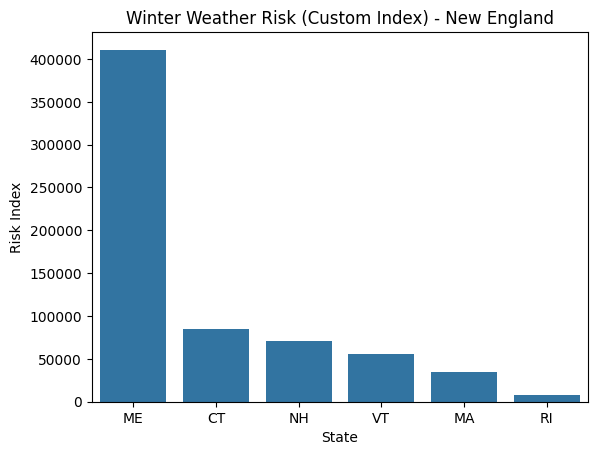


Top 10 High-Risk Census Tracts:

         TRACTFIPS STATEABBRV  CUSTOM_RISK  POPULATION
33623  23019002000         ME  7369.121196        7709
33658  23019031100         ME  6252.308555        6578
33699  23027042000         ME  6111.000000        6111
33702  23027045000         ME  5995.109691        6099
33700  23027043000         ME  5289.167398        6937
33704  23027046002         ME  5065.691540        5173
33636  23019010000         ME  4877.655689        6461
33622  23019000900         ME  4715.753606        6430
33635  23019009000         ME  4547.417848        6311
33660  23019031300         ME  4286.536463        5994


In [25]:
# ---------------------------
# 1. LOAD DATA
# ---------------------------
nri = pd.read_csv("NRI_Table_CensusTracts.csv")

# Optional SVI dataset
try:
    svi = pd.read_csv("SVI_CensusTracts.csv")
    use_svi = True
except:
    use_svi = False

# ---------------------------
# 2. FILTER NEW ENGLAND STATES
# ---------------------------
new_england_states = ['CT', 'ME', 'MA', 'NH', 'RI', 'VT']

nri_ne = nri[nri['STATEABBRV'].isin(new_england_states)].copy()

# ---------------------------
# 3. SELECT HAZARD
# ---------------------------
hazard_prefix = "WNTW"  # Winter Weather

# Common NRI columns (may vary slightly by version)
eal_col = f"{hazard_prefix}_EALT"
risk_score_col = f"{hazard_prefix}_RISKS"

# ---------------------------
# 4. CLEAN + PREP VARIABLES
# ---------------------------
nri_ne = nri_ne[[ 'TRACTFIPS', 'STATEABBRV', 'POPULATION',
                  eal_col, risk_score_col ]].copy()

nri_ne = nri_ne.dropna()

# Normalize EAL to avoid scaling issues
nri_ne['EAL_norm'] = (nri_ne[eal_col] - nri_ne[eal_col].min()) / \
                     (nri_ne[eal_col].max() - nri_ne[eal_col].min())

# ---------------------------
# 5. MERGE SVI 
# ---------------------------
if use_svi:
    svi = svi[['FIPS', 'SVI']].copy()
    svi.columns = ['TRACTFIPS', 'SVI']

    nri_ne = nri_ne.merge(svi, on='TRACTFIPS', how='left')
    nri_ne['SVI'] = nri_ne['SVI'].fillna(nri_ne['SVI'].mean())
else:
    nri_ne['SVI'] = 1  # neutral if not used

# ---------------------------
# 6. CREATE CUSTOM RISK METRIC
# ---------------------------
nri_ne['CUSTOM_RISK'] = (
    nri_ne['EAL_norm'] *
    nri_ne['POPULATION'] *
    nri_ne['SVI']
)

# ---------------------------
# 7. AGGREGATE BY STATE
# ---------------------------
state_summary = nri_ne.groupby('STATEABBRV').agg({
    'CUSTOM_RISK': 'sum',
    'POPULATION': 'sum',
    eal_col: 'sum'
}).reset_index()

state_summary = state_summary.sort_values(by='CUSTOM_RISK', ascending=False)

print("\nState-Level Risk Summary:\n")
print(state_summary)

# ---------------------------
# 8. VISUALIZATION
# ---------------------------
plt.figure()
sns.barplot(data=state_summary, x='STATEABBRV', y='CUSTOM_RISK')
plt.title("Winter Weather Risk (Custom Index) - New England")
plt.xlabel("State")
plt.ylabel("Risk Index")
plt.show()

# ---------------------------
# 9. MOST AT-RISK TRACTS
# ---------------------------
top_tracts = nri_ne.sort_values(by='CUSTOM_RISK', ascending=False).head(10)

print("\nTop 10 High-Risk Census Tracts:\n")
print(top_tracts[['TRACTFIPS', 'STATEABBRV', 'CUSTOM_RISK', 'POPULATION']])

In [26]:
tracts = gpd.read_file('NRI_ShapeFile_CensusTracts.shp')
tracts.head()
tracts.crs
tracts.geometry.head()

0    POLYGON ((-9626784.493 3827718.774, -9626802.4...
1    POLYGON ((-9625497.973 3827700.43, -9625504.76...
2    POLYGON ((-9623646.617 3823891.992, -9623666.3...
3    POLYGON ((-9622012.001 3826514.039, -9622007.2...
4    POLYGON ((-9619304.709 3823820.353, -9619304.3...
Name: geometry, dtype: geometry

In [28]:
tracts_clean = tracts.set_crs(epsg = 4326, inplace = True, allow_override = True)
tracts_clean = tracts_clean.to_crs(epsg=4326)
tracts_clean = tracts_clean.replace(-9999, np.nan)

In [29]:
tracts_clean.crs = "EPSG:3857"
tracts_clean = tracts_clean.to_crs(epsg=4326)
tracts_clean = tracts_clean.to_crs("ESRI:102003")
tracts_clean.head()

,NRI_ID,STATE,STATEABBRV,STATEFIPS,COUNTY,COUNTYTYPE,COUNTYFIPS,STCOFIPS,TRACT,TRACTFIPS,...,WNTW_ALRP,WNTW_ALRA,WNTW_ALR_N,WNTW_RISKV,WNTW_RISKS,WNTW_RISKR,NRI_VER,Shape_Leng,Shape_Area,geometry
0,T01001020100,Alabama,AL,01,Autauga,County,001,01001,020100,01001020100,...,7.410082e-09,0.000009,32.947366,214.404773,25.882367,Relatively Low,March 2023,19225.811017,1.388551e+07,"POLYGON ((888436.979 -515916.275, 888434.788 -..."
1,T01001020200,Alabama,AL,01,Autauga,County,001,01001,020200,01001020200,...,7.410082e-09,0.000009,33.845738,335.526352,29.020596,Relatively Low,March 2023,11645.802680,4.687259e+06,"POLYGON ((889513.324 -515823.588, 889509.56 -5..."
2,T01001020300,Alabama,AL,01,Autauga,County,001,01001,020300,01001020300,...,7.410082e-09,0.000009,33.386570,494.226826,32.839033,Relatively Low,March 2023,12474.652420,7.550456e+06,"POLYGON ((891382.825 -518869.923, 891366.236 -..."
3,T01001020400,Alabama,AL,01,Autauga,County,001,01001,020400,01001020400,...,7.410082e-09,0.000009,32.654955,517.167844,33.357513,Relatively Low,March 2023,14839.600848,9.007297e+06,"POLYGON ((892526.253 -516527.408, 892530.7 -51..."
4,T01001020501,Alabama,AL,01,Autauga,County,001,01001,020501,01001020501,...,7.410082e-09,0.000009,32.793527,558.901021,34.226799,Relatively Low,March 2023,13543.791893,8.736313e+06,"POLYGON ((895017.426 -518563.572, 895057.475 -..."


In [30]:
print(tracts_clean)

             NRI_ID           STATE STATEABBRV STATEFIPS      COUNTY  \
0      T01001020100         Alabama         AL        01     Autauga   
1      T01001020200         Alabama         AL        01     Autauga   
2      T01001020300         Alabama         AL        01     Autauga   
3      T01001020400         Alabama         AL        01     Autauga   
4      T01001020501         Alabama         AL        01     Autauga   
...             ...             ...        ...       ...         ...   
85149  T78030960800  Virgin Islands         VI        78  St. Thomas   
85150  T78030960900  Virgin Islands         VI        78  St. Thomas   
85151  T78030961000  Virgin Islands         VI        78  St. Thomas   
85152  T78030961100  Virgin Islands         VI        78  St. Thomas   
85153  T78030961200  Virgin Islands         VI        78  St. Thomas   

      COUNTYTYPE COUNTYFIPS STCOFIPS   TRACT    TRACTFIPS  ...     WNTW_ALRP  \
0         County        001    01001  020100  010010201

In [31]:
exclude = ['Alaska', 'Hawaii', 'Puerto Rico', 'American Samoa', 
           'Guam', 'Northern Mariana Islands', 'Virgin Islands']
tracts_lower48 = tracts_clean[~tracts_clean['STATE'].isin(exclude)]
tracts_lower48

,NRI_ID,STATE,STATEABBRV,STATEFIPS,COUNTY,COUNTYTYPE,COUNTYFIPS,STCOFIPS,TRACT,TRACTFIPS,...,WNTW_ALRP,WNTW_ALRA,WNTW_ALR_N,WNTW_RISKV,WNTW_RISKS,WNTW_RISKR,NRI_VER,Shape_Leng,Shape_Area,geometry
0,T01001020100,Alabama,AL,01,Autauga,County,001,01001,020100,01001020100,...,7.410082e-09,8.725777e-06,32.947366,214.404773,25.882367,Relatively Low,March 2023,19225.811017,1.388551e+07,"POLYGON ((888436.979 -515916.275, 888434.788 -..."
1,T01001020200,Alabama,AL,01,Autauga,County,001,01001,020200,01001020200,...,7.410082e-09,8.725777e-06,33.845738,335.526352,29.020596,Relatively Low,March 2023,11645.802680,4.687259e+06,"POLYGON ((889513.324 -515823.588, 889509.56 -5..."
2,T01001020300,Alabama,AL,01,Autauga,County,001,01001,020300,01001020300,...,7.410082e-09,8.725777e-06,33.386570,494.226826,32.839033,Relatively Low,March 2023,12474.652420,7.550456e+06,"POLYGON ((891382.825 -518869.923, 891366.236 -..."
3,T01001020400,Alabama,AL,01,Autauga,County,001,01001,020400,01001020400,...,7.410082e-09,8.725777e-06,32.654955,517.167844,33.357513,Relatively Low,March 2023,14839.600848,9.007297e+06,"POLYGON ((892526.253 -516527.408, 892530.7 -51..."
4,T01001020501,Alabama,AL,01,Autauga,County,001,01001,020501,01001020501,...,7.410082e-09,8.725777e-06,32.793527,558.901021,34.226799,Relatively Low,March 2023,13543.791893,8.736313e+06,"POLYGON ((895017.426 -518563.572, 895057.475 -..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84088,T56043000200,Wyoming,WY,56,Washakie,County,043,56043,000200,56043000200,...,9.531082e-08,1.287620e-08,70.626160,3931.706833,69.546449,Relatively Moderate,March 2023,572737.235735,1.115772e+10,"POLYGON ((-886600.549 798062.562, -886495.444 ..."
84089,T56043000301,Wyoming,WY,56,Washakie,County,043,56043,000301,56043000301,...,8.555953e-08,0.000000e+00,69.402494,2679.820329,61.751415,Relatively Moderate,March 2023,8168.796638,3.854767e+06,"POLYGON ((-952241.582 788354.789, -952348.24 7..."
84090,T56043000302,Wyoming,WY,56,Washakie,County,043,56043,000302,56043000302,...,8.555953e-08,1.134591e-08,69.314419,2624.207069,61.318556,Relatively Moderate,March 2023,46110.862093,3.118148e+07,"POLYGON ((-952241.582 788354.789, -952225.402 ..."
84091,T56045951100,Wyoming,WY,56,Weston,County,045,56045,951100,56045951100,...,5.573649e-07,3.473970e-07,96.752942,48721.038246,97.765543,Very High,March 2023,516549.117884,1.173870e+10,"POLYGON ((-673491.52 777689.159, -673087.416 7..."


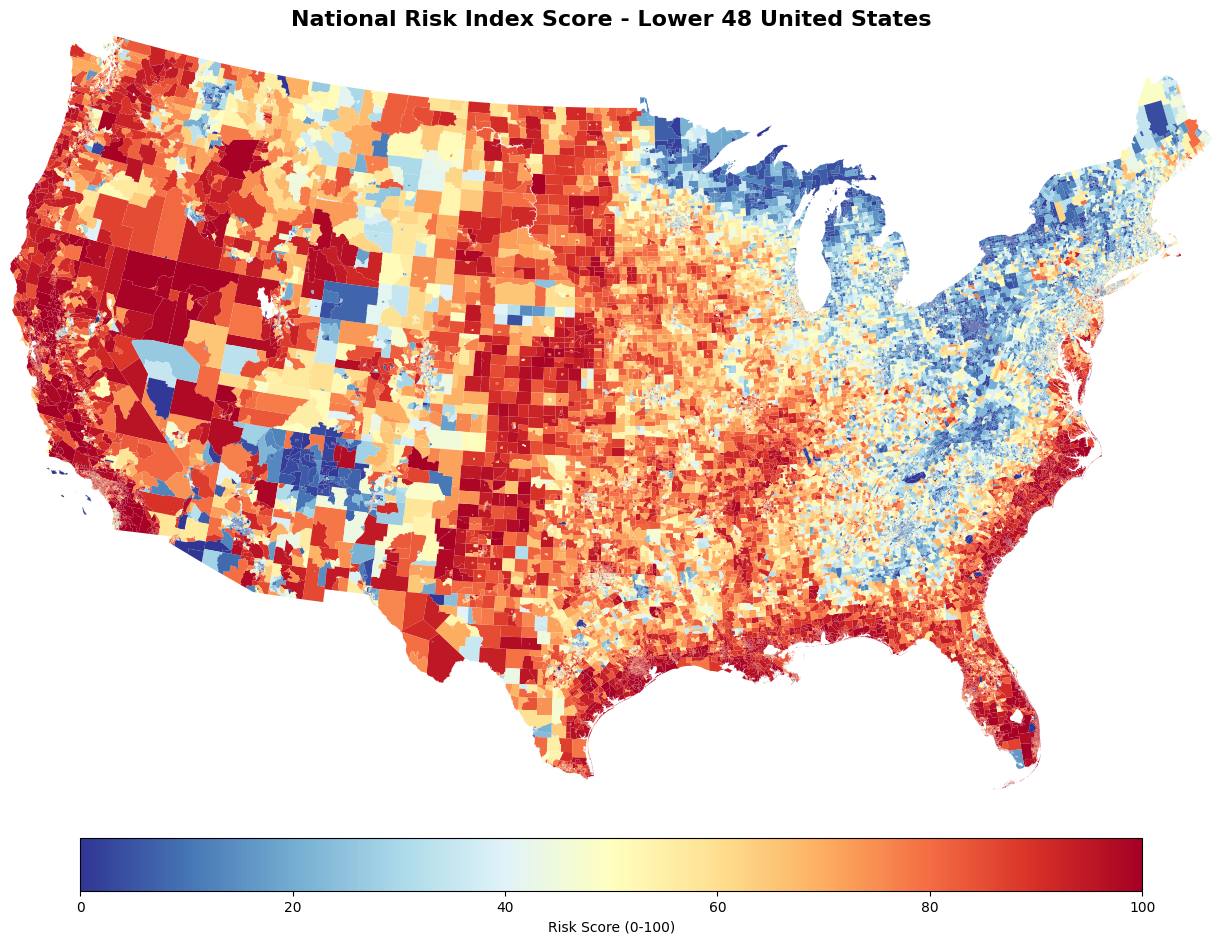

In [32]:
fig, ax=plt.subplots(1,1,figsize=(18,10))
tracts_lower48.plot(
    column="RISK_SCORE",
    cmap="RdYlBu_r",
    linewidth=0.0,
    ax=ax,
    legend=True,
    legend_kwds={"label":"Risk Score (0-100)", "orientation": "horizontal", "shrink": 0.6, "pad": 0.05},
    missing_kwds={"color": "lightgrey", "label":"No Data"},
)
minx, miny, maxx, maxy = tracts_lower48.total_bounds
padding = 0.5
ax.set_xlim(minx - padding, maxx + padding)
ax.set_ylim(miny - padding, maxy + padding)
ax.set_title("National Risk Index Score - Lower 48 United States", fontsize=16, fontweight="bold")
ax.set_axis_off()
plt.tight_layout()
plt.show()

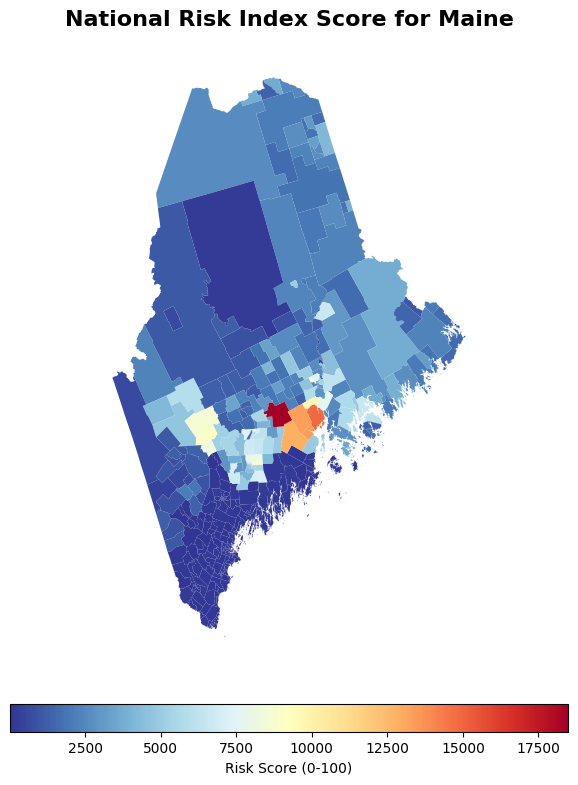

In [35]:
state_name = "Maine"
state_map = tracts_clean[tracts_clean["STATE"] == state_name]
fig,ax = plt.subplots(1,1, figsize=(12,10))
state_map.plot(
    column = "WNTW_RISKV",
    cmap = "RdYlBu_r",
    aspect = 1,
    linewidth = 0.0,
    ax=ax,
    legend = True,
    legend_kwds = {"label": "Risk Score (0-100)", "orientation": "horizontal", "shrink": 0.6, "pad": 0.05},
    missing_kwds = {"color": "lightgrey", "label": "No Data"},
)

ax.set_title("National Risk Index Score for Maine", fontsize = 16, fontweight = "bold")
ax.set_axis_off()
plt.show()

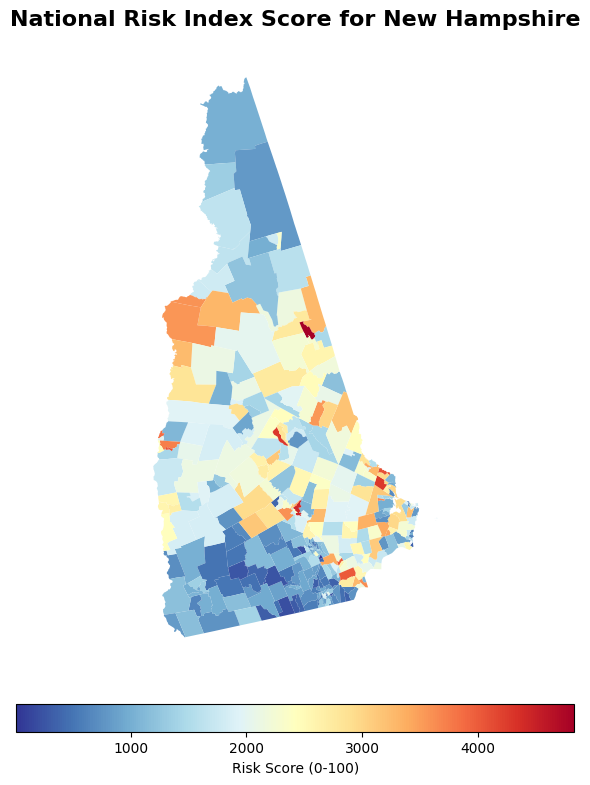

In [36]:
state_name = "New Hampshire"
state_map = tracts_clean[tracts_clean["STATE"] == state_name]
fig,ax = plt.subplots(1,1, figsize=(12,10))
state_map.plot(
    column = "WNTW_RISKV",
    cmap = "RdYlBu_r",
    aspect = 1,
    linewidth = 0.0,
    ax=ax,
    legend = True,
    legend_kwds = {"label": "Risk Score (0-100)", "orientation": "horizontal", "shrink": 0.6, "pad": 0.05},
    missing_kwds = {"color": "lightgrey", "label": "No Data"},
)

ax.set_title("National Risk Index Score for New Hampshire", fontsize = 16, fontweight = "bold")
ax.set_axis_off()
plt.show()

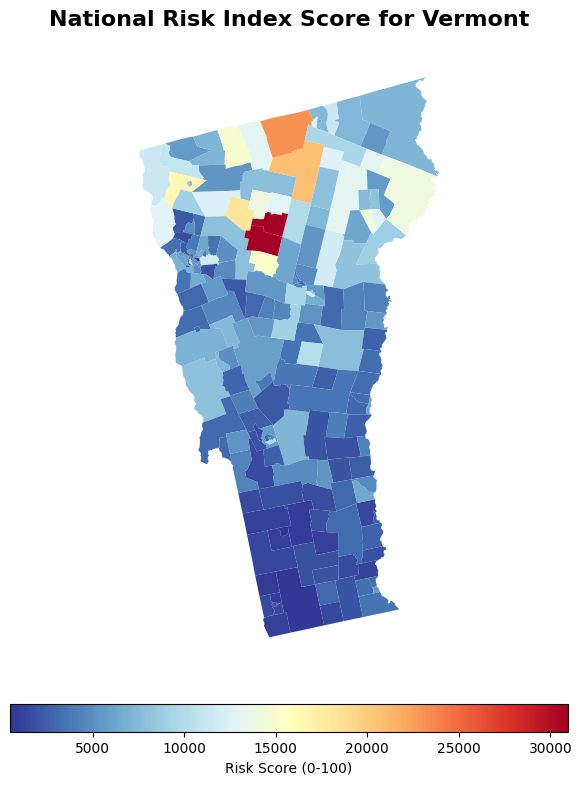

In [37]:
state_name = "Vermont"
state_map = tracts_clean[tracts_clean["STATE"] == state_name]
fig,ax = plt.subplots(1,1, figsize=(12,10))
state_map.plot(
    column = "WNTW_RISKV",
    cmap = "RdYlBu_r",
    aspect = 1,
    linewidth = 0.0,
    ax=ax,
    legend = True,
    legend_kwds = {"label": "Risk Score (0-100)", "orientation": "horizontal", "shrink": 0.6, "pad": 0.05},
    missing_kwds = {"color": "lightgrey", "label": "No Data"},
)

ax.set_title("National Risk Index Score for Vermont", fontsize = 16, fontweight = "bold")
ax.set_axis_off()
plt.show()

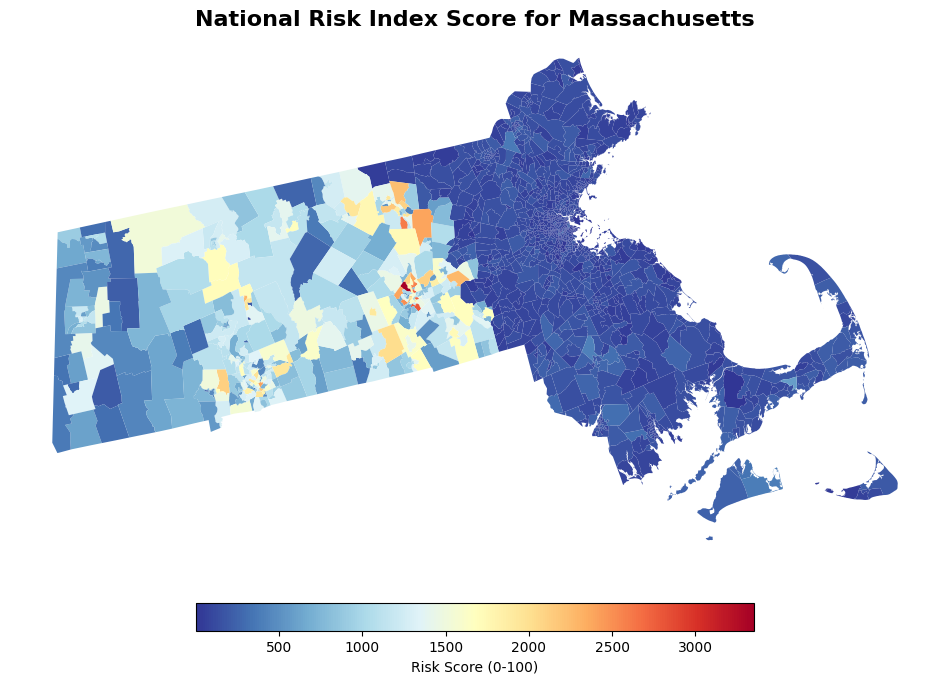

In [38]:
state_name = "Massachusetts"
state_map = tracts_clean[tracts_clean["STATE"] == state_name]
fig,ax = plt.subplots(1,1, figsize=(12,10))
state_map.plot(
    column = "WNTW_RISKV",
    cmap = "RdYlBu_r",
    aspect = 1,
    linewidth = 0.0,
    ax=ax,
    legend = True,
    legend_kwds = {"label": "Risk Score (0-100)", "orientation": "horizontal", "shrink": 0.6, "pad": 0.05},
    missing_kwds = {"color": "lightgrey", "label": "No Data"},
)

ax.set_title("National Risk Index Score for Massachusetts", fontsize = 16, fontweight = "bold")
ax.set_axis_off()
plt.show()

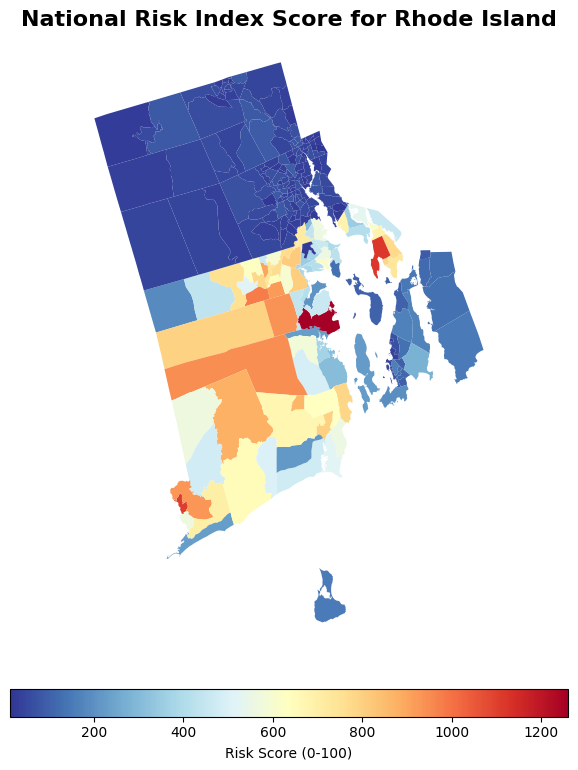

In [39]:
state_name = "Rhode Island"
state_map = tracts_clean[tracts_clean["STATE"] == state_name]
fig,ax = plt.subplots(1,1, figsize=(12,10))
state_map.plot(
    column = "WNTW_RISKV",
    cmap = "RdYlBu_r",
    aspect = 1,
    linewidth = 0.0,
    ax=ax,
    legend = True,
    legend_kwds = {"label": "Risk Score (0-100)", "orientation": "horizontal", "shrink": 0.6, "pad": 0.05},
    missing_kwds = {"color": "lightgrey", "label": "No Data"},
)

ax.set_title("National Risk Index Score for Rhode Island", fontsize = 16, fontweight = "bold")
ax.set_axis_off()
plt.show()

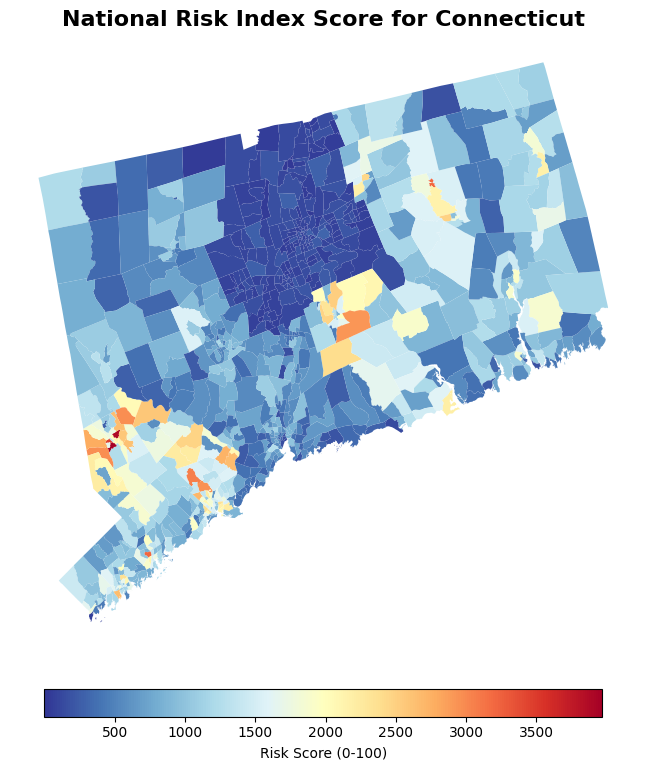

In [40]:
state_name = "Connecticut"
state_map = tracts_clean[tracts_clean["STATE"] == state_name]
fig,ax = plt.subplots(1,1, figsize=(12,10))
state_map.plot(
    column = "WNTW_RISKV",
    cmap = "RdYlBu_r",
    aspect = 1,
    linewidth = 0.0,
    ax=ax,
    legend = True,
    legend_kwds = {"label": "Risk Score (0-100)", "orientation": "horizontal", "shrink": 0.6, "pad": 0.05},
    missing_kwds = {"color": "lightgrey", "label": "No Data"},
)

ax.set_title("National Risk Index Score for Connecticut", fontsize = 16, fontweight = "bold")
ax.set_axis_off()
plt.show()